# 📰 Fake News Detection using Graph ML
## Notebook 2: Graph Construction + Feature Engineering

**What we build here:**
- A **heterogeneous graph** where:
  - **Nodes** = News articles, Speakers, Subjects
  - **Edges** = Speaker made statement, Statement belongs to subject
- Node features using **TF-IDF** and one-hot encodings
- Save graph as `PyTorch Geometric` Data object

```
[Speaker] ──spoke──▶ [Article] ──about──▶ [Subject]
```

## Step 1 — Install Libraries

In [1]:
!pip install torch torchvision torchaudio -q
!pip install torch-geometric -q
!pip install networkx matplotlib scikit-learn pandas -q
print('✅ Done installing!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.2 MB/s eta 0:00:00
✅ Done installing!


In [2]:
import pandas as pd
import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from torch_geometric.data import Data
import os, pickle, warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries loaded | Device: {device}')

✅ Libraries loaded | Device: cuda


## Step 2 — Load Processed Data

In [3]:
train_df = pd.read_csv('/content/data/train-2.csv')
val_df   = pd.read_csv('/content/data/val.csv')
test_df  = pd.read_csv('/content/data/test-2.csv')

# Combine all splits — graph is built on all data, masks separate train/val/test
df = pd.concat([train_df, val_df, test_df], ignore_index=True)
df['binary_label'] = df['binary_label'].fillna(1).astype(int)
df['speaker']  = df['speaker'].fillna('unknown')
df['subject']  = df['subject'].fillna('unknown')
df['statement'] = df['statement'].fillna('')

print(f'Total statements: {len(df):,}')
df.head(3)

Total statements: 12,791


,id,label,statement,subject,speaker,job,state,party,barely_true,false,half_true,mostly_true,pants_on_fire,context,label_name,binary_label,stmt_len
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,false,1,11.0
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,half-true,0,24.0
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,mostly-true,0,19.0


## Step 3 — Build the Graph

### Node types
| Type | Description | Feature |
|------|-------------|------|
| Article | Each news statement | TF-IDF (500-dim) |
| Speaker | Person who made the claim | One-hot encoded |
| Subject | Topic of the statement | One-hot encoded |

### Edge types
| Type | Meaning |
|------|---------|
| speaker→article | This speaker made this statement |
| article→subject | This statement is about this subject |

In [4]:
# ── Encode speakers and subjects ──────────────────────────────────────────────
speaker_enc = LabelEncoder()
subject_enc = LabelEncoder()
df['speaker_id'] = speaker_enc.fit_transform(df['speaker'])
df['subject_id'] = subject_enc.fit_transform(df['subject'])

n_articles = len(df)
n_speakers = df['speaker_id'].nunique()
n_subjects = df['subject_id'].nunique()

print(f'Nodes — Articles: {n_articles:,} | Speakers: {n_speakers:,} | Subjects: {n_subjects:,}')
print(f'Total nodes     : {n_articles + n_speakers + n_subjects:,}')

Nodes — Articles: 12,791 | Speakers: 3,310 | Subjects: 4,535
Total nodes     : 20,636


In [5]:
# ── Node features ─────────────────────────────────────────────────────────────
# Article features: TF-IDF on statement text (500 features)
tfidf = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2))
article_feats = tfidf.fit_transform(df['statement']).toarray().astype(np.float32)  # (N_art, 500)

# Speaker features: one-hot (n_speakers, n_speakers) — identity matrix
speaker_feats = np.eye(n_speakers, dtype=np.float32)  # (N_spk, N_spk)

# Subject features: one-hot
subject_feats = np.eye(n_subjects, dtype=np.float32)  # (N_sub, N_sub)

# Pad all features to the same dim (max of 500, n_speakers, n_subjects)
feat_dim = max(500, n_speakers, n_subjects)

def pad(arr, dim):
    pad_width = dim - arr.shape[1]
    if pad_width > 0:
        arr = np.hstack([arr, np.zeros((arr.shape[0], pad_width), dtype=np.float32)])
    return arr

article_feats = pad(article_feats, feat_dim)
speaker_feats = pad(speaker_feats, feat_dim)
subject_feats = pad(subject_feats, feat_dim)

# Concatenate all node features: [articles | speakers | subjects]
all_feats = np.vstack([article_feats, speaker_feats, subject_feats])  # (N_total, feat_dim)
x = torch.tensor(all_feats, dtype=torch.float)

print(f'Node feature matrix shape: {x.shape}  (total_nodes x feat_dim)')

Node feature matrix shape: torch.Size([20636, 4535])  (total_nodes x feat_dim)


In [6]:
# ── Build edge list ────────────────────────────────────────────────────────────
# Node ID offsets
spk_offset = n_articles
sub_offset = n_articles + n_speakers

src_edges, dst_edges = [], []

for idx, row in df.iterrows():
    art_node = idx
    spk_node = spk_offset + row['speaker_id']
    sub_node = sub_offset + row['subject_id']

    # Speaker ↔ Article (bidirectional)
    src_edges += [spk_node, art_node]
    dst_edges += [art_node, spk_node]

    # Article ↔ Subject (bidirectional)
    src_edges += [art_node, sub_node]
    dst_edges += [sub_node, art_node]

edge_index = torch.tensor([src_edges, dst_edges], dtype=torch.long)
print(f'Edge index shape: {edge_index.shape}  ({edge_index.shape[1]:,} edges total)')

Edge index shape: torch.Size([2, 51164])  (51,164 edges total)


In [7]:
# ── Labels and masks (article nodes only) ──────────────────────────────────────
y = torch.tensor(df['binary_label'].values, dtype=torch.long)

n_train = len(train_df)
n_val   = len(val_df)
n_test  = len(test_df)

train_mask = torch.zeros(len(df), dtype=torch.bool)
val_mask   = torch.zeros(len(df), dtype=torch.bool)
test_mask  = torch.zeros(len(df), dtype=torch.bool)

train_mask[:n_train] = True
val_mask[n_train:n_train+n_val] = True
test_mask[n_train+n_val:] = True

print(f'Labels shape : {y.shape}')
print(f'Train mask   : {train_mask.sum().item():,} nodes')
print(f'Val mask     : {val_mask.sum().item():,} nodes')
print(f'Test mask    : {test_mask.sum().item():,} nodes')

Labels shape : torch.Size([12791])
Train mask   : 10,240 nodes
Val mask     : 1,284 nodes
Test mask    : 1,267 nodes


In [8]:
# ── Assemble PyG Data object ───────────────────────────────────────────────────
# We only predict on article nodes (first n_articles nodes)
# Extend labels + masks to cover all nodes (speaker/subject nodes get label=-1)
full_y = torch.full((x.shape[0],), -1, dtype=torch.long)
full_y[:n_articles] = y

full_train = torch.zeros(x.shape[0], dtype=torch.bool)
full_val   = torch.zeros(x.shape[0], dtype=torch.bool)
full_test  = torch.zeros(x.shape[0], dtype=torch.bool)
full_train[:n_articles] = train_mask
full_val[:n_articles]   = val_mask
full_test[:n_articles]  = test_mask

graph_data = Data(
    x          = x,
    edge_index = edge_index,
    y          = full_y,
    train_mask = full_train,
    val_mask   = full_val,
    test_mask  = full_test,
    num_classes= 2
)

print('\n✅ PyTorch Geometric Data object:')
print(graph_data)
print(f'\nIs undirected: {graph_data.is_undirected()}')


✅ PyTorch Geometric Data object:
Data(x=[20636, 4535], edge_index=[2, 51164], y=[20636], train_mask=[20636], val_mask=[20636], test_mask=[20636], num_classes=2)

Is undirected: True


## Step 4 — Visualize a Sample of the Graph

Sample graph — Nodes: 136 | Edges: 100


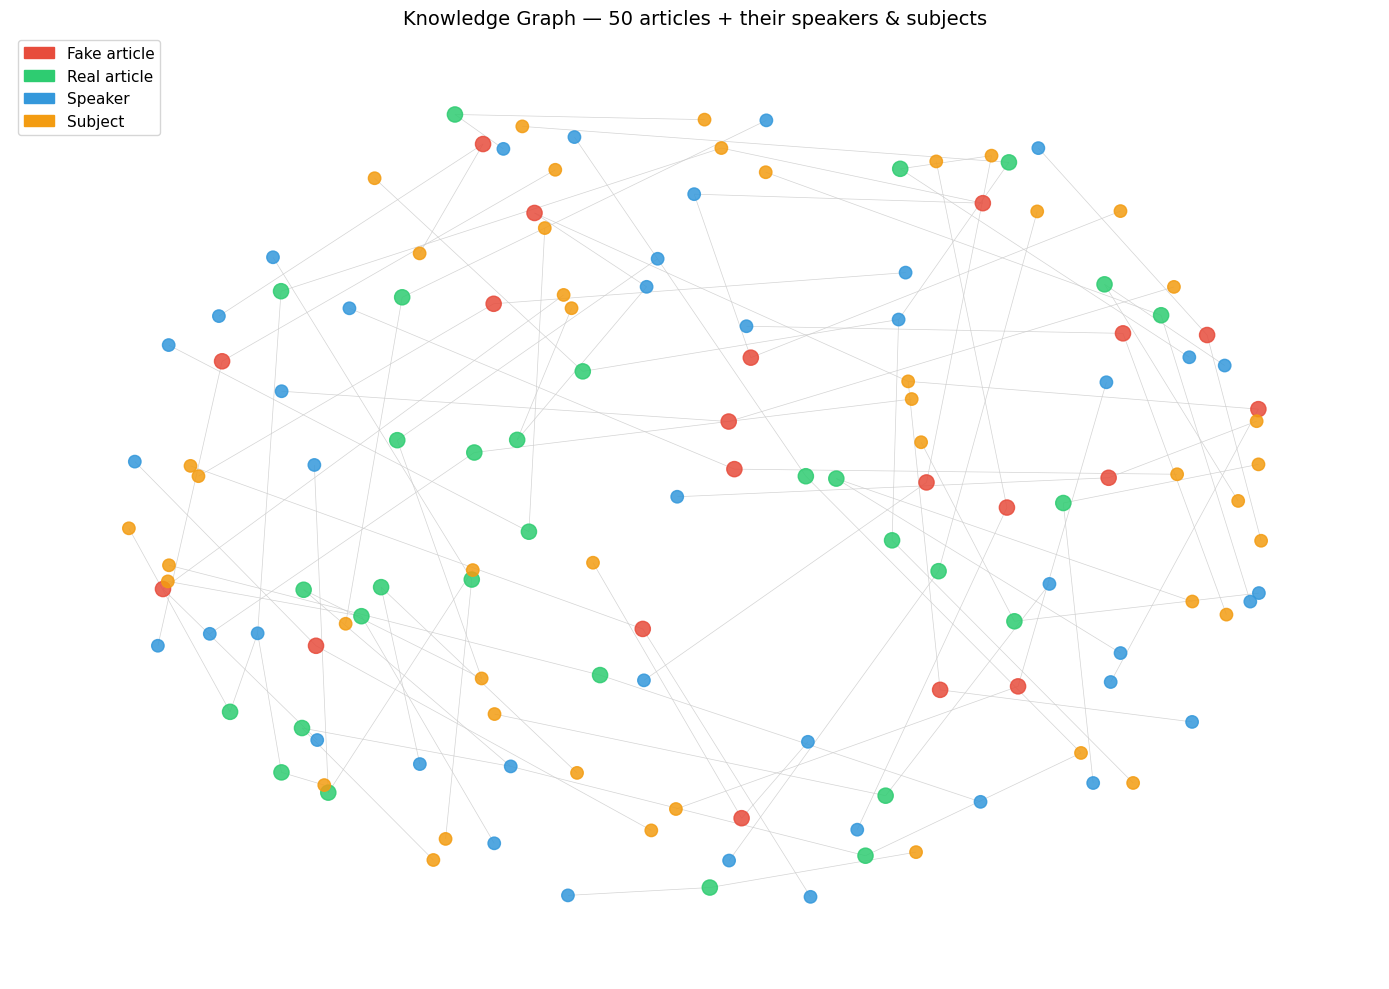

📊 Graph saved as graph_visualization.png


In [9]:
# Build a small NetworkX subgraph for visualization (first 50 articles + their neighbors)
G = nx.Graph()

SAMPLE = 50  # number of article nodes to visualize
sample_idx = list(range(SAMPLE))

node_colors = []
node_sizes  = []
node_labels = {}

# Add article nodes
for i in sample_idx:
    label = df.iloc[i]['binary_label']
    G.add_node(i, node_type='article', label=label)
    node_colors.append('#e74c3c' if label == 1 else '#2ecc71')
    node_sizes.append(120)
    node_labels[i] = ''

# Add speaker and subject nodes connected to sample articles
added_speakers = {}
added_subjects = {}

for i in sample_idx:
    row = df.iloc[i]
    spk = f"spk_{row['speaker_id']}"
    sub = f"sub_{row['subject_id']}"

    if spk not in G:
        G.add_node(spk, node_type='speaker')
        node_colors.append('#3498db')
        node_sizes.append(80)
        node_labels[spk] = ''

    if sub not in G:
        G.add_node(sub, node_type='subject')
        node_colors.append('#f39c12')
        node_sizes.append(80)
        node_labels[sub] = ''

    G.add_edge(i, spk)
    G.add_edge(i, sub)

print(f'Sample graph — Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}')

# Draw
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.6, seed=42)
nx.draw_networkx(G, pos,
                 node_color=node_colors,
                 node_size=node_sizes,
                 labels=node_labels,
                 edge_color='#cccccc',
                 width=0.5,
                 alpha=0.85)

legend = [
    mpatches.Patch(color='#e74c3c', label='Fake article'),
    mpatches.Patch(color='#2ecc71', label='Real article'),
    mpatches.Patch(color='#3498db', label='Speaker'),
    mpatches.Patch(color='#f39c12', label='Subject'),
]
plt.legend(handles=legend, loc='upper left', fontsize=11)
plt.title(f'Knowledge Graph — {SAMPLE} articles + their speakers & subjects', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('graph_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Graph saved as graph_visualization.png')

## Step 5 — Save Graph for Training

In [10]:
os.makedirs('data', exist_ok=True)
torch.save(graph_data, 'data/graph_data.pt')

# Save metadata
meta = {
    'n_articles': n_articles,
    'n_speakers': n_speakers,
    'n_subjects': n_subjects,
    'feat_dim'  : feat_dim,
    'n_train'   : n_train,
    'n_val'     : n_val,
    'n_test'    : n_test,
}
with open('data/meta.pkl', 'wb') as f:
    pickle.dump(meta, f)

print('✅ Graph saved to data/graph_data.pt')
print('✅ Metadata saved to data/meta.pkl')
print(f'\nGraph summary:')
print(f'  Total nodes : {graph_data.num_nodes:,}')
print(f'  Total edges : {graph_data.num_edges:,}')
print(f'  Node features: {graph_data.num_node_features}')


✅ Graph saved to data/graph_data.pt
✅ Metadata saved to data/meta.pkl

Graph summary:
  Total nodes : 20,636
  Total edges : 51,164
  Node features: 4535


In [11]:
import torch
torch.save(graph_data, '/content/data/graph_data.pt')
print("saved")

saved


## Notebook 3: GNN Model Training

**Models we train and compare:**
| Model | Key idea |
|-------|----------|
| **GCN** | Averages neighbor features (spectral convolution) |
| **GAT** | Learns *attention weights* over neighbors |
| **GraphSAGE** | Samples + aggregates neighbors (scales to large graphs) |

**Task:** Binary node classification — Fake (1) vs Real (0)

In [12]:
!pip install torch-geometric scikit-learn matplotlib -q
print('✅ Ready!')

✅ Ready!


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle, os

from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')

✅ Device: cuda


In [18]:
import torch, pickle

graph_data = torch.load(
    '/content/data/graph_data.pt',
    weights_only=False   # ⭐ IMPORTANT FIX
)

with open('/content/data/meta.pkl', 'rb') as f:
    meta = pickle.load(f)

graph_data = graph_data.to(device)

print("✅ Loaded successfully")

✅ Loaded successfully


In [19]:
print(graph_data)

Data(x=[20636, 4535], edge_index=[2, 51164], y=[20636], train_mask=[20636], val_mask=[20636], test_mask=[20636], num_classes=2)


## Step 3 — Define GNN Models

All three models follow the same 2-layer structure:
```
Input (feat_dim) → GNN Layer 1 (128) → ReLU → Dropout → GNN Layer 2 (64) → Linear → Softmax
```

In [20]:
# ── GCN ───────────────────────────────────────────────────────────────────────
class GCN(nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1   = GCNConv(in_dim, hidden)
        self.conv2   = GCNConv(hidden, hidden // 2)
        self.linear  = nn.Linear(hidden // 2, out_dim)
        self.dropout = dropout

    def forward(self, data):
        x, ei = data.x, data.edge_index
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, ei))
        x = self.linear(x)
        return F.log_softmax(x, dim=1), x  # (logits, embeddings)

# ── GAT ───────────────────────────────────────────────────────────────────────
class GAT(nn.Module):
    def __init__(self, in_dim, hidden=64, out_dim=2, heads=4, dropout=0.5):
        super().__init__()
        self.conv1  = GATConv(in_dim, hidden, heads=heads, dropout=dropout)
        self.conv2  = GATConv(hidden * heads, hidden, heads=1, concat=False, dropout=dropout)
        self.linear = nn.Linear(hidden, out_dim)
        self.dropout = dropout

    def forward(self, data):
        x, ei = data.x, data.edge_index
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, ei))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv2(x, ei))
        x = self.linear(x)
        return F.log_softmax(x, dim=1), x

# ── GraphSAGE ─────────────────────────────────────────────────────────────────
class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1  = SAGEConv(in_dim, hidden)
        self.conv2  = SAGEConv(hidden, hidden // 2)
        self.linear = nn.Linear(hidden // 2, out_dim)
        self.dropout = dropout

    def forward(self, data):
        x, ei = data.x, data.edge_index
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, ei))
        x = self.linear(x)
        return F.log_softmax(x, dim=1), x

print('✅ GCN, GAT, GraphSAGE defined!')

✅ GCN, GAT, GraphSAGE defined!


## Step 4 — Training Loop

In [21]:
def train_model(model, data, epochs=100, lr=0.01, weight_decay=5e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0
    best_state   = None

    model.train()
    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        optimizer.zero_grad()
        out, _ = model(data)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        scheduler.step()

        # ── Validate ──
        model.eval()
        with torch.no_grad():
            out, _ = model(data)
            val_loss = F.nll_loss(out[data.val_mask], data.y[data.val_mask]).item()
            pred = out.argmax(dim=1)

            t_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
            v_acc = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean().item()

        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 20 == 0:
            print(f'Epoch {epoch:3d} | Loss: {loss.item():.4f} | Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f}')

    model.load_state_dict(best_state)  # restore best weights
    print(f'\n🏆 Best Val Acc: {best_val_acc:.4f}')
    return history

print('✅ Training function ready!')

✅ Training function ready!


## Step 5 — Train All Three Models

In [25]:
IN_DIM = graph_data.num_node_features
OUT_DIM = 2

print("Input dim:", IN_DIM)



Input dim: 4535


In [26]:
# ── GCN ─────────────────────────────────────
print('=' * 50)
print('Training GCN...')
print('=' * 50)

gcn_model = GCN(in_dim=IN_DIM).to(device)
gcn_history = train_model(gcn_model, graph_data, epochs=100)

Training GCN...
Epoch  20 | Loss: 0.5485 | Train Acc: 0.7618 | Val Acc: 0.6207
Epoch  40 | Loss: 0.4408 | Train Acc: 0.8227 | Val Acc: 0.6098
Epoch  60 | Loss: 0.3938 | Train Acc: 0.8475 | Val Acc: 0.5974
Epoch  80 | Loss: 0.3598 | Train Acc: 0.8621 | Val Acc: 0.6028
Epoch 100 | Loss: 0.3391 | Train Acc: 0.8735 | Val Acc: 0.6083

🏆 Best Val Acc: 0.6277


In [27]:
 # ── GAT ───────────────────────────────────────────────────────────────────────
print('=' * 50)
print('Training GAT...')
print('=' * 50)
gat_model = GAT(in_dim=IN_DIM).to(device)
gat_history = train_model(gat_model, graph_data, epochs=100)

Training GAT...
Epoch  20 | Loss: 0.6414 | Train Acc: 0.7138 | Val Acc: 0.6324
Epoch  40 | Loss: 0.6270 | Train Acc: 0.7383 | Val Acc: 0.6160
Epoch  60 | Loss: 0.6207 | Train Acc: 0.7508 | Val Acc: 0.5903
Epoch  80 | Loss: 0.6197 | Train Acc: 0.7624 | Val Acc: 0.6005
Epoch 100 | Loss: 0.6171 | Train Acc: 0.7622 | Val Acc: 0.5950

🏆 Best Val Acc: 0.6324


In [28]:
# ── GraphSAGE ─────────────────────────────────────────────────────────────────
print('=' * 50)
print('Training GraphSAGE...')
print('=' * 50)
sage_model = GraphSAGE(in_dim=IN_DIM).to(device)
sage_history = train_model(sage_model, graph_data, epochs=100)

Training GraphSAGE...
Epoch  20 | Loss: 0.4014 | Train Acc: 0.8436 | Val Acc: 0.6129
Epoch  40 | Loss: 0.2073 | Train Acc: 0.9651 | Val Acc: 0.6106
Epoch  60 | Loss: 0.1104 | Train Acc: 0.9926 | Val Acc: 0.6153
Epoch  80 | Loss: 0.0792 | Train Acc: 0.9979 | Val Acc: 0.6246
Epoch 100 | Loss: 0.0638 | Train Acc: 0.9989 | Val Acc: 0.6129

🏆 Best Val Acc: 0.6371


## Step 6 — Evaluate on Test Set

In [29]:
def evaluate(model, data, name='Model'):
    model.eval()
    with torch.no_grad():
        out, embeddings = model(data)
        pred  = out.argmax(dim=1)
        probs = torch.exp(out)[:, 1]  # probability of fake

    mask = data.test_mask
    y_true  = data.y[mask].cpu().numpy()
    y_pred  = pred[mask].cpu().numpy()
    y_prob  = probs[mask].cpu().numpy()

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    auc = roc_auc_score(y_true, y_prob)

    print(f'\n{" " + name + " Test Results ":=^50}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1 Score : {f1:.4f}')
    print(f'  AUC-ROC  : {auc:.4f}')
    print(f'\n{classification_report(y_true, y_pred, target_names=["Real", "Fake"])}')

    return {'name': name, 'acc': acc, 'f1': f1, 'auc': auc,
            'embeddings': embeddings[:meta['n_articles']].cpu().numpy(),
            'y_true': y_true, 'y_pred': y_pred}

gcn_results  = evaluate(gcn_model,  graph_data, 'GCN')
gat_results  = evaluate(gat_model,  graph_data, 'GAT')
sage_results = evaluate(sage_model, graph_data, 'GraphSAGE')


================ GCN Test Results ================
  Accuracy : 0.6046
  F1 Score : 0.5945
  AUC-ROC  : 0.6383

              precision    recall  f1-score   support

        Real       0.64      0.68      0.66       714
        Fake       0.55      0.51      0.53       553

    accuracy                           0.60      1267
   macro avg       0.60      0.59      0.59      1267
weighted avg       0.60      0.60      0.60      1267


================ GAT Test Results ================
  Accuracy : 0.6196
  F1 Score : 0.5996
  AUC-ROC  : 0.6470

              precision    recall  f1-score   support

        Real       0.64      0.75      0.69       714
        Fake       0.58      0.45      0.51       553

    accuracy                           0.62      1267
   macro avg       0.61      0.60      0.60      1267
weighted avg       0.61      0.62      0.61      1267


============= GraphSAGE Test Results =============
  Accuracy : 0.6314
  F1 Score : 0.6167
  AUC-ROC  : 0.6673

       

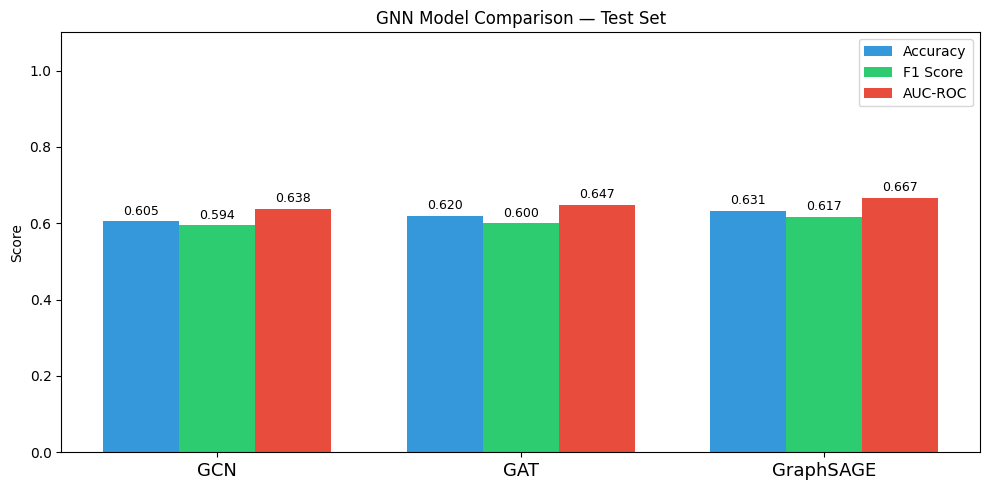

In [30]:
# ── Model comparison bar chart ─────────────────────────────────────────────────
models   = ['GCN', 'GAT', 'GraphSAGE']
acc_vals = [gcn_results['acc'],  gat_results['acc'],  sage_results['acc']]
f1_vals  = [gcn_results['f1'],   gat_results['f1'],   sage_results['f1']]
auc_vals = [gcn_results['auc'],  gat_results['auc'],  sage_results['auc']]

x = np.arange(len(models))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w,   acc_vals, w, label='Accuracy', color='#3498db')
ax.bar(x,       f1_vals,  w, label='F1 Score', color='#2ecc71')
ax.bar(x + w,   auc_vals, w, label='AUC-ROC',  color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=13)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('GNN Model Comparison — Test Set')
ax.legend()

for i, (a, f, u) in enumerate(zip(acc_vals, f1_vals, auc_vals)):
    ax.text(i - w,   a + 0.01, f'{a:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i,       f + 0.01, f'{f:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + w,   u + 0.01, f'{u:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

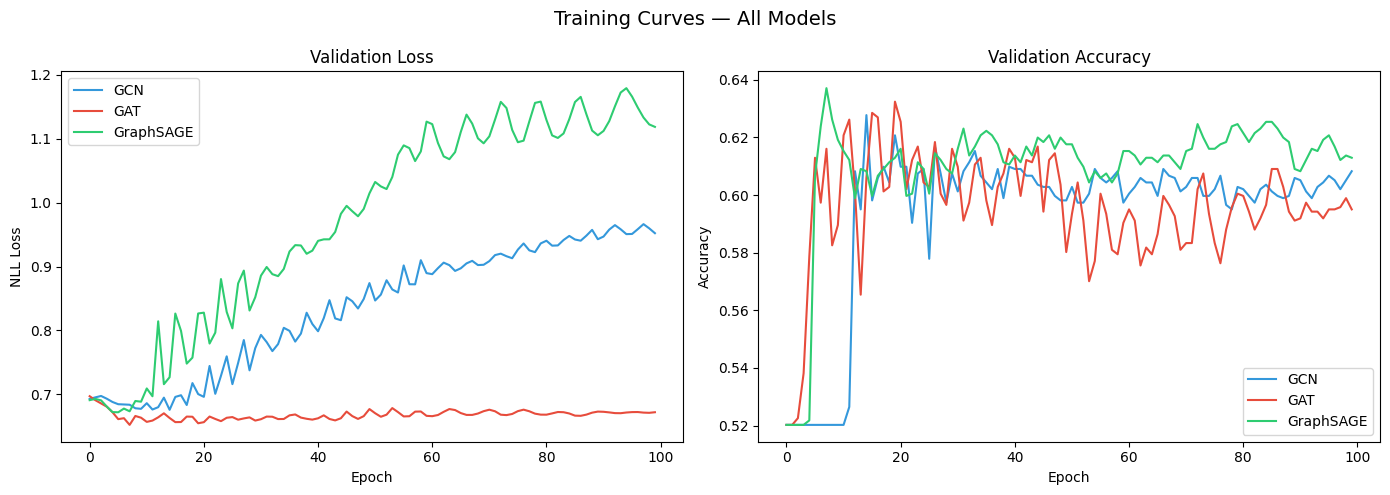

In [31]:
# ── Training curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, label, color in [
    (gcn_history,  'GCN',       '#3498db'),
    (gat_history,  'GAT',       '#e74c3c'),
    (sage_history, 'GraphSAGE', '#2ecc71'),
]:
    axes[0].plot(hist['val_loss'], label=label, color=color)
    axes[1].plot(hist['val_acc'],  label=label, color=color)

axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('NLL Loss')
axes[0].legend()

axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Training Curves — All Models', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Save Models & Results

In [35]:
import os

os.makedirs('results', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

In [36]:
os.makedirs('models', exist_ok=True)
torch.save(gcn_model.state_dict(),  '/content/models/gcn.pt')
torch.save(gat_model.state_dict(),  '/content/models/gat.pt')
torch.save(sage_model.state_dict(), '/content/models/sage.pt')

results_df = pd.DataFrame([gcn_results, gat_results, sage_results])[['name', 'acc', 'f1', 'auc']]
results_df.to_csv('results/metrics.csv', index=False)

# Save embeddings for visualization
with open('data/results.pkl', 'wb') as f:
    pickle.dump({'gcn': gcn_results, 'gat': gat_results, 'sage': sage_results}, f)

print('✅ Models saved to models/')
print('✅ Results saved to results/')
print(results_df.to_string(index=False))
print('\n🚀 Ready for Notebook 4: Visualization!')

✅ Models saved to models/
✅ Results saved to results/
     name      acc       f1      auc
      GCN 0.604578 0.594473 0.638306
      GAT 0.619574 0.599597 0.646983
GraphSAGE 0.631413 0.616728 0.667287

🚀 Ready for Notebook 4: Visualization!


In [37]:
!pip install torch-geometric scikit-learn matplotlib seaborn -q
print('✅ Ready!')

✅ Ready!


In [38]:
import torch, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import torch.nn.functional as F

from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, roc_curve, auc
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
import torch.nn as nn

os.makedirs('results', exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
print(f'✅ Libraries loaded | Device: {device}')

✅ Libraries loaded | Device: cuda


## Step 1 — Load Data & Saved Models

In [41]:
# Load graph and metadata
graph_data = torch.load(
    '/content/data/graph_data.pt',
    weights_only=False
).to(device)
with open('/content/data/meta.pkl', 'rb') as f:
    meta = pickle.load(f)
with open('/content/data/results.pkl', 'rb') as f:
    saved_results = pickle.load(f)

train_df = pd.read_csv('/content/data/train-2.csv')
val_df   = pd.read_csv('/content/data/val.csv')
test_df  = pd.read_csv('/content/data/test-2.csv')
df       = pd.concat([train_df, val_df, test_df], ignore_index=True)

IN_DIM = graph_data.num_node_features
print(f'✅ Data loaded | Feature dim: {IN_DIM}')

✅ Data loaded | Feature dim: 4535


In [42]:
# Re-define and reload models
class GCN(nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1   = GCNConv(in_dim, hidden)
        self.conv2   = GCNConv(hidden, hidden // 2)
        self.linear  = nn.Linear(hidden // 2, out_dim)
        self.dropout = dropout
    def forward(self, data):
        x, ei = data.x, data.edge_index
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, ei))
        x = self.linear(x)
        return F.log_softmax(x, dim=1), x

class GAT(nn.Module):
    def __init__(self, in_dim, hidden=64, out_dim=2, heads=4, dropout=0.5):
        super().__init__()
        self.conv1  = GATConv(in_dim, hidden, heads=heads, dropout=dropout)
        self.conv2  = GATConv(hidden * heads, hidden, heads=1, concat=False, dropout=dropout)
        self.linear = nn.Linear(hidden, out_dim)
        self.dropout = dropout
    def forward(self, data, return_attention=False):
        x, ei = data.x, data.edge_index
        x = F.dropout(x, p=self.dropout, training=self.training)
        if return_attention:
            x, (edge_idx, alpha1) = self.conv1(x, ei, return_attention_weights=True)
        else:
            x = self.conv1(x, ei)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv2(x, ei))
        x = self.linear(x)
        if return_attention:
            return F.log_softmax(x, dim=1), x, alpha1.mean(dim=1), edge_idx
        return F.log_softmax(x, dim=1), x

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1  = SAGEConv(in_dim, hidden)
        self.conv2  = SAGEConv(hidden, hidden // 2)
        self.linear = nn.Linear(hidden // 2, out_dim)
        self.dropout = dropout
    def forward(self, data):
        x, ei = data.x, data.edge_index
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, ei))
        x = self.linear(x)
        return F.log_softmax(x, dim=1), x

gcn_model  = GCN(IN_DIM).to(device)
gat_model  = GAT(IN_DIM).to(device)
sage_model = GraphSAGE(IN_DIM).to(device)

gcn_model.load_state_dict(torch.load('models/gcn.pt',  map_location=device))
gat_model.load_state_dict(torch.load('models/gat.pt',  map_location=device))
sage_model.load_state_dict(torch.load('models/sage.pt', map_location=device))

for m in [gcn_model, gat_model, sage_model]:
    m.eval()

print('✅ All models loaded and in eval mode')

✅ All models loaded and in eval mode


## Step 2 — t-SNE Embedding Visualization

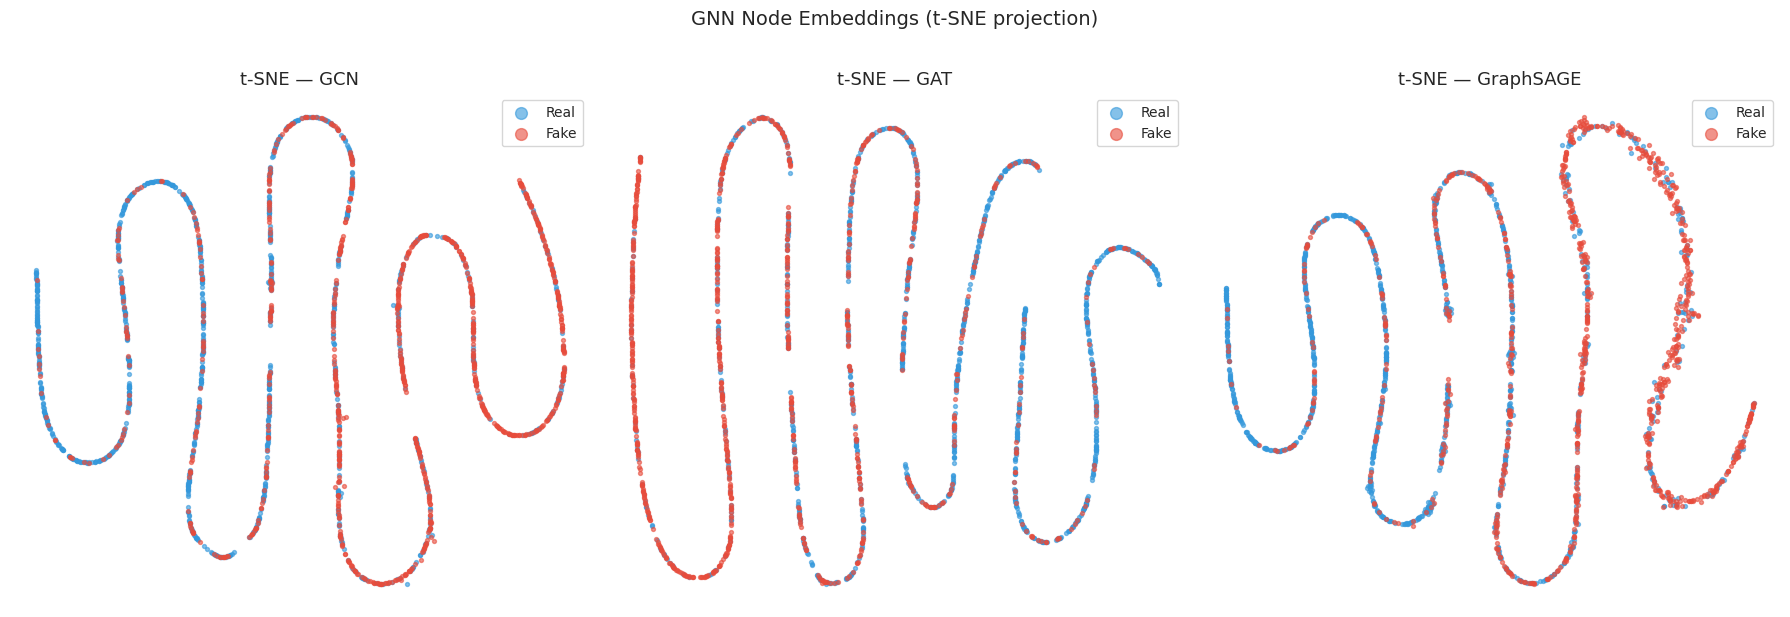

📊 t-SNE plot saved!


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_list = [
    (gcn_model,  'GCN',        '#3498db', '#e74c3c'),
    (gat_model,  'GAT',        '#3498db', '#e74c3c'),
    (sage_model, 'GraphSAGE',  '#3498db', '#e74c3c'),
]

n_art = meta['n_articles']
y_all = graph_data.y[:n_art].cpu().numpy()

for ax, (model, name, c_real, c_fake) in zip(axes, models_list):
    with torch.no_grad():
        _, emb = model(graph_data)
    emb_np = emb[:n_art].cpu().numpy()

    # t-SNE on a random sample of 2000 nodes for speed
    sample_idx = np.random.choice(n_art, size=min(2000, n_art), replace=False)
    emb_sample = emb_np[sample_idx]
    y_sample   = y_all[sample_idx]

    tsne  = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=500)
    z     = tsne.fit_transform(emb_sample)

    real_mask = y_sample == 0
    fake_mask = y_sample == 1

    ax.scatter(z[real_mask, 0], z[real_mask, 1], c=c_real, s=8, alpha=0.6, label='Real')
    ax.scatter(z[fake_mask, 0], z[fake_mask, 1], c=c_fake, s=8, alpha=0.6, label='Fake')
    ax.set_title(f't-SNE — {name}', fontsize=13)
    ax.legend(markerscale=3)
    ax.axis('off')

plt.suptitle('GNN Node Embeddings (t-SNE projection)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('results/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 t-SNE plot saved!')

## Step 3 — Confusion Matrices

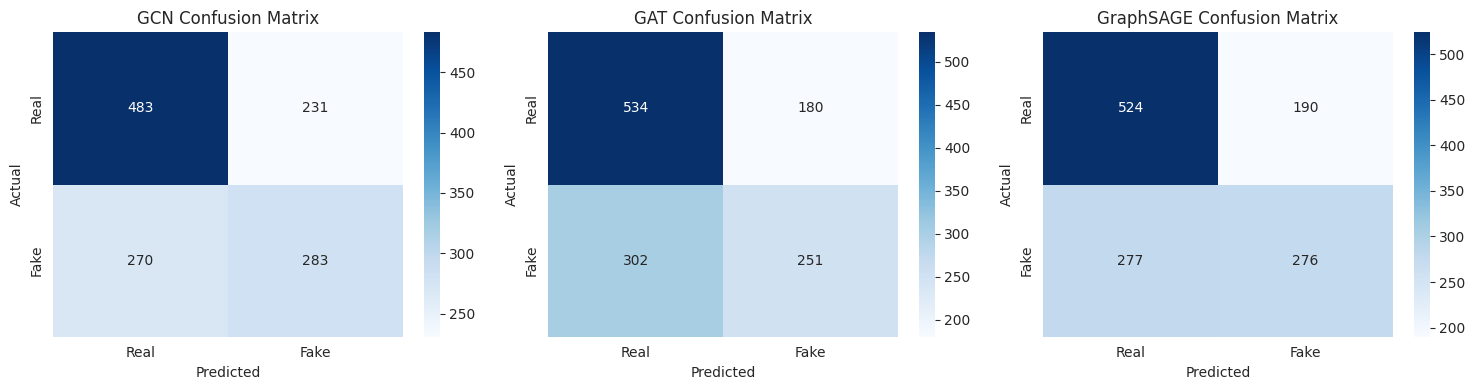

📊 Confusion matrices saved!


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model, name) in zip(axes, [
    (gcn_model, 'GCN'), (gat_model, 'GAT'), (sage_model, 'GraphSAGE')
]):
    with torch.no_grad():
        out, _ = model(graph_data)
    pred   = out.argmax(dim=1)
    y_true = graph_data.y[graph_data.test_mask].cpu().numpy()
    y_pred = pred[graph_data.test_mask].cpu().numpy()

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('results/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Confusion matrices saved!')

## Step 4 — ROC Curves

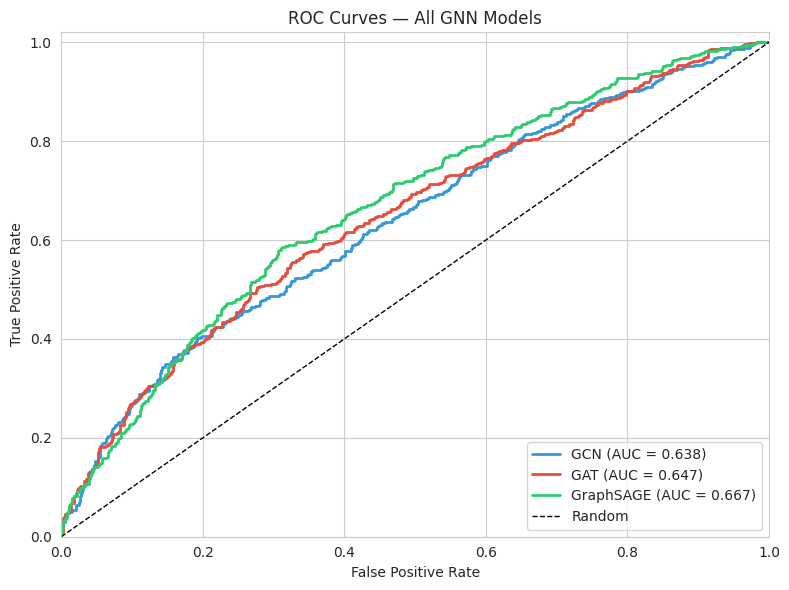

📊 ROC curves saved!


In [45]:
plt.figure(figsize=(8, 6))

colors = {'GCN': '#3498db', 'GAT': '#e74c3c', 'GraphSAGE': '#2ecc71'}

for model, name in [(gcn_model, 'GCN'), (gat_model, 'GAT'), (sage_model, 'GraphSAGE')]:
    with torch.no_grad():
        out, _ = model(graph_data)
    probs  = torch.exp(out)[:, 1]  # probability of fake
    y_true = graph_data.y[graph_data.test_mask].cpu().numpy()
    y_prob = probs[graph_data.test_mask].cpu().numpy()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[name], lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All GNN Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('results/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 ROC curves saved!')

## Step 5 — GAT Attention Weight Heatmap

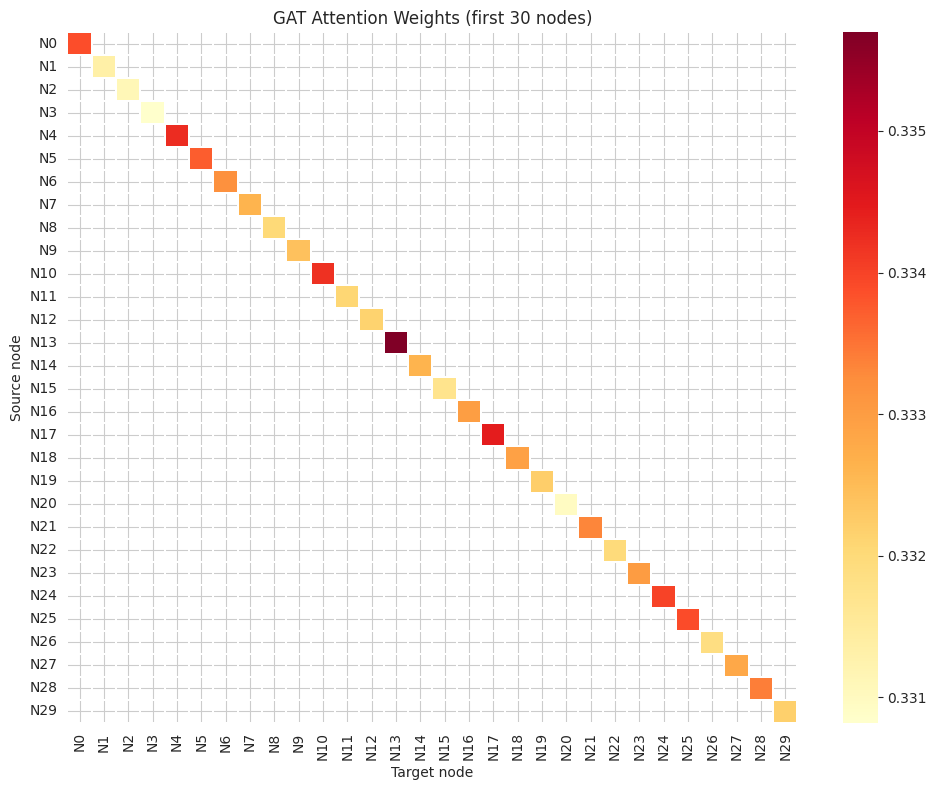

📊 GAT attention heatmap saved!


In [46]:
gat_model.eval()
with torch.no_grad():
    _, _, attn_weights, edge_idx = gat_model(graph_data, return_attention=True)

# Visualize attention for a small subgraph (first 30 article nodes)
attn_np   = attn_weights.cpu().numpy()
edge_src  = edge_idx[0].cpu().numpy()
edge_dst  = edge_idx[1].cpu().numpy()

# Build 30x30 attention matrix for article-article attention (through shared speakers)
N = 30
attn_matrix = np.zeros((N, N))

for i, (s, d, w) in enumerate(zip(edge_src, edge_dst, attn_np)):
    if s < N and d < N:
        attn_matrix[s, d] = w

plt.figure(figsize=(10, 8))
mask = attn_matrix == 0
sns.heatmap(attn_matrix,
            mask=mask,
            cmap='YlOrRd',
            linewidths=0.3,
            xticklabels=[f'N{i}' for i in range(N)],
            yticklabels=[f'N{i}' for i in range(N)])
plt.title('GAT Attention Weights (first 30 nodes)')
plt.xlabel('Target node')
plt.ylabel('Source node')
plt.tight_layout()
plt.savefig('results/gat_attention.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 GAT attention heatmap saved!')

## Step 6 — Final Graph with Predicted Labels

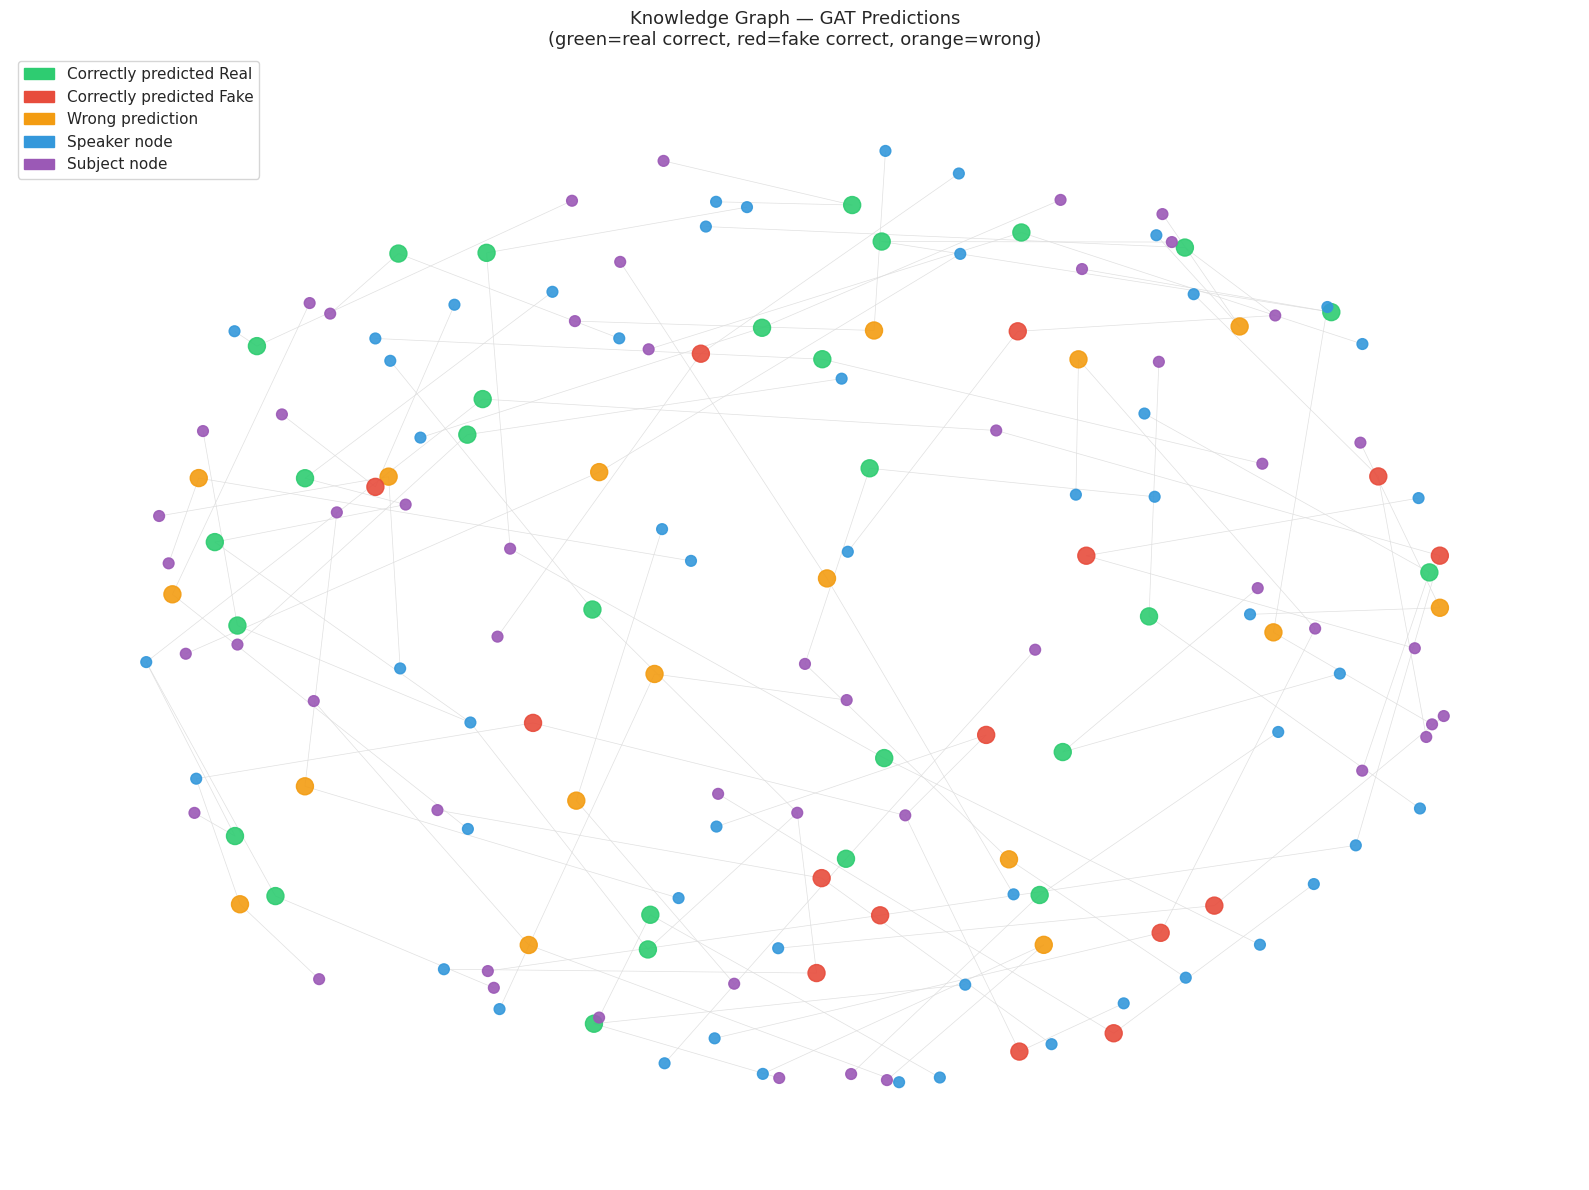

📊 Prediction graph saved to results/


In [47]:
# Use GAT (best attention model) predictions on a 60-node subgraph
gat_model.eval()
with torch.no_grad():
    out, _ = gat_model(graph_data)
preds_all = out.argmax(dim=1).cpu().numpy()
truth_all = graph_data.y.cpu().numpy()

# Build sample subgraph
SAMPLE = 60
G = nx.Graph()
node_colors, node_sizes, node_shapes = [], [], []

for i in range(SAMPLE):
    pred  = preds_all[i]
    truth = truth_all[i]
    correct = (pred == truth)
    # Color: correct=green/pink, wrong=orange
    if correct:
        color = '#2ecc71' if pred == 0 else '#e74c3c'
    else:
        color = '#f39c12'   # wrong prediction
    G.add_node(i, node_type='article')
    node_colors.append(color)
    node_sizes.append(150)

# Add speaker/subject nodes
from sklearn.preprocessing import LabelEncoder
se = LabelEncoder().fit(df['speaker'])
su = LabelEncoder().fit(df['subject'])
df['sid'] = se.transform(df['speaker'])
df['subid'] = su.transform(df['subject'])

n_art = meta['n_articles']
n_spk = meta['n_speakers']

for i in range(SAMPLE):
    spk_key = f"s_{df.iloc[i]['sid']}"
    sub_key = f"t_{df.iloc[i]['subid']}"
    if spk_key not in G:
        G.add_node(spk_key, node_type='speaker')
        node_colors.append('#3498db')
        node_sizes.append(60)
    if sub_key not in G:
        G.add_node(sub_key, node_type='subject')
        node_colors.append('#9b59b6')
        node_sizes.append(60)
    G.add_edge(i, spk_key)
    G.add_edge(i, sub_key)

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=0.5, seed=42)
nx.draw_networkx(G, pos,
                 node_color=node_colors,
                 node_size=node_sizes,
                 labels={n: '' for n in G.nodes()},
                 edge_color='#dddddd',
                 width=0.5, alpha=0.9)

legend_handles = [
    mpatches.Patch(color='#2ecc71', label='Correctly predicted Real'),
    mpatches.Patch(color='#e74c3c', label='Correctly predicted Fake'),
    mpatches.Patch(color='#f39c12', label='Wrong prediction'),
    mpatches.Patch(color='#3498db', label='Speaker node'),
    mpatches.Patch(color='#9b59b6', label='Subject node'),
]
plt.legend(handles=legend_handles, loc='upper left', fontsize=11)
plt.title('Knowledge Graph — GAT Predictions\n(green=real correct, red=fake correct, orange=wrong)', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig('results/predicted_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Prediction graph saved to results/')



### Summary of all outputs
| File | Description |
|------|-------------|
| `results/tsne_embeddings.png` | 2D embedding clusters for all 3 models |
| `results/confusion_matrices.png` | Confusion matrices |
| `results/roc_curves.png` | ROC curves comparison |
| `results/gat_attention.png` | GAT attention heatmap |
| `results/predicted_graph.png` | Final knowledge graph with predictions |
| `results/metrics.csv` | Accuracy, F1, AUC table |